In [1]:
import numpy as np
from matplotlib import pyplot as plt
from diptest import diptest

In [2]:
# load 4D VAE scores
data = np.loadtxt("4D_representation_all.csv", delimiter=',', skiprows=1)

In [3]:
# run diptest on many random 1D projections of the data
# Parameters
n_proj = 100000
rng = np.random.default_rng(42)

# --- Run dip test on real data ---
dip_real = []
pval_real = []
vectors_real = []

for _ in range(n_proj):
    v = rng.normal(size=data.shape[1])
    v /= np.linalg.norm(v)
    y = data @ v
    dip, pval = diptest(y)
    dip_real.append(dip)
    pval_real.append(pval)
    vectors_real.append(v)

dip_real = np.array(dip_real)
pval_real = np.array(pval_real)
vectors_real = np.array(vectors_real)

In [4]:
# --- Generate null data (multivariate Gaussian with same mean and covariance) ---

# Compute covariance of your real data
cov = np.cov(data, rowvar=False)
mean = np.mean(data, axis=0)

n_samples = data.shape[0]
null_data = rng.multivariate_normal(mean=mean, cov=cov, size=n_samples)

dip_null = []
pval_null = []

for _ in range(n_proj):
    v = rng.normal(size=null_data.shape[1])
    v /= np.linalg.norm(v)
    y = null_data @ v
    dip, pval = diptest(y)
    dip_null.append(dip)
    pval_null.append(pval)

dip_null = np.array(dip_null)
pval_null = np.array(pval_null)

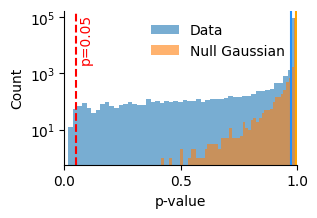

Mean p-value: Data = 0.9746, Null = 0.9959


In [5]:
# --- Compare histograms of pvals between real and simulated data ---
plt.figure(figsize=(3,2))
plt.hist(pval_real, bins=50, alpha=0.6, label='Data', log=True)
plt.hist(pval_null, bins=50, alpha=0.6, label='Null Gaussian', log=True)
plt.axvline(0.05, color='red', linestyle='--')
plt.axvline(np.mean(pval_real), color='dodgerblue', linestyle='-')
plt.axvline(np.mean(pval_null), color='orange', linestyle='-')
plt.xlim(0,1)
plt.xticks([0, 0.5,1.])
plt.xlabel("p-value")
plt.ylabel("Count")
plt.legend(frameon=False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
y_max = ax.get_ylim()[1]
plt.text(0.05 + 0.01, y_max*0.8, "p=0.05", color='red', rotation=90, va='top', fontweight='normal')
plt.savefig("diptest_histo.png", dpi=600, bbox_inches="tight")
plt.show()

print(f"Mean p-value: Data = {np.mean(pval_real):.4f}, Null = {np.mean(pval_null):.4f}")

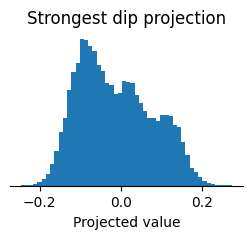

In [6]:
# Find the projection with the smallest p-value and plot histogram of data via that projection
best_idx = np.argmin(pval_real)
v_best = vectors_real[best_idx]
y_best = data @ v_best

plt.figure(figsize=(3,2))
plt.hist(y_best, bins=50)
# plt.title(f"Strongest dip projection (p={pval_real[best_idx]:.3g})")
plt.title(f"Strongest dip projection")
plt.xlabel("Projected value")
plt.yticks([])
# plt.ylabel("Count")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

plt.savefig("Strong_dip.png", dpi=600, bbox_inches="tight")

plt.show()

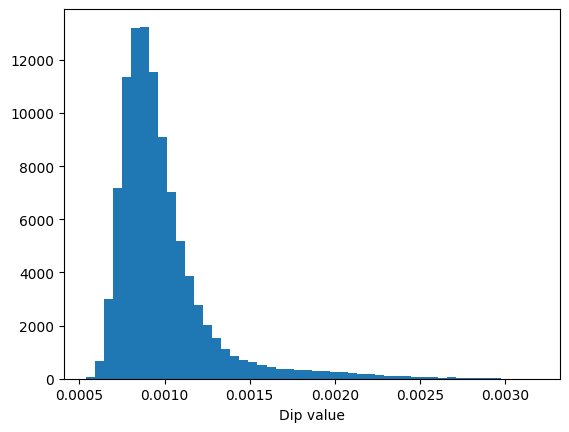

In [7]:
# histogram of dip values
plt.hist(dip_real, bins=50)
plt.xlabel("Dip value")
# plt.ylabel("Count")
plt.show()

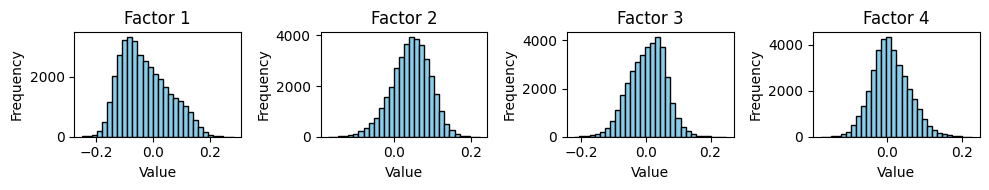

In [8]:
# Histograms of original values
fig, axes = plt.subplots(1, 4, figsize=(10, 2))  # 2x2 grid of subplots

for i, ax in enumerate(axes.flat):
    ax.hist(data[:, i], bins=30, color='skyblue', edgecolor='black')
    ax.set_title(f'Factor {i+1}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [9]:
print(v_best)

[ 0.78259803  0.21857082 -0.514903    0.27320691]


In [10]:
import pandas as pd

from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind

In [11]:
df_full = pd.read_csv("HQ_Data_Clean_new.csv")   # contains subject_sp_id + features
age_df  = pd.read_csv("rbsr-new.csv")            # contains subject_sp_id + age_at_eval_years

if "subject_sp_id" not in df_full.columns:
    raise ValueError("HQ_Data_Clean_new.csv must contain 'subject_sp_id'")
if not {"subject_sp_id", "age_at_eval_years"}.issubset(age_df.columns):
    raise ValueError("rbsr-new.csv must contain 'subject_sp_id' and 'age_at_eval_years'")

# -----------------------
# Align ages to df_full row order (critical)
# -----------------------
age_map = age_df[["subject_sp_id", "age_at_eval_years"]].drop_duplicates("subject_sp_id")
ages_all = (
    df_full[["subject_sp_id"]]
    .merge(age_map, on="subject_sp_id", how="left")["age_at_eval_years"]
    .to_numpy()
)

In [12]:
from keras.models import load_model
from keras.saving import register_keras_serializable
from tensorflow import keras
import tensorflow as tf

@register_keras_serializable()

class Sampling(keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

encoding_size = 4

df_full = pd.read_csv("HQ_Data_Clean_new.csv") 
df = df_full.drop(columns=["subject_sp_id"])
x = df.to_numpy(dtype=np.float32)

In [13]:
# -----------------------
# Encode every person through all 100 VAEs
# -----------------------
num_runs = 100
z_means_runs = []

for run in range(num_runs):

    encoder_path = f"saved_models/encoder_run{run+1}.h5"

    encoder = load_model(
        encoder_path,
        custom_objects={"Sampling": Sampling},
        compile=False
    )

    z_mean, _, _ = encoder.predict(x, verbose=0)

    z_means_runs.append(z_mean)

z_means_runs = np.stack(z_means_runs, axis=0)   # shape: (100, N, 4)

z_mean_avg = z_means_runs.mean(axis=0)          # shape: (N, 4)

latent_df_avg = pd.DataFrame(
    z_mean_avg,
    columns=["z1", "z2", "z3", "z4"]
)


In [14]:
gmm = GaussianMixture(
    n_components=3,
    covariance_type="full",
    random_state=42
)

labels = gmm.fit_predict(z_mean_avg)
probs = gmm.predict_proba(z_mean_avg)

original_df_new = df.copy()

original_df_new["cluster"] = labels
original_df_new["confidence"] = probs.max(axis=1)
original_df_new["P_cluster0"] = probs[:, 0]
original_df_new["P_cluster1"] = probs[:, 1]
original_df_new["P_cluster2"] = probs[:, 2]

In [15]:
pca_new = PCA(n_components=2)

latent_new=z_mean_avg

pc_new = pca_new.fit_transform(latent_new)

print(pca_new.explained_variance_ratio_)

[0.57747895 0.21906626]


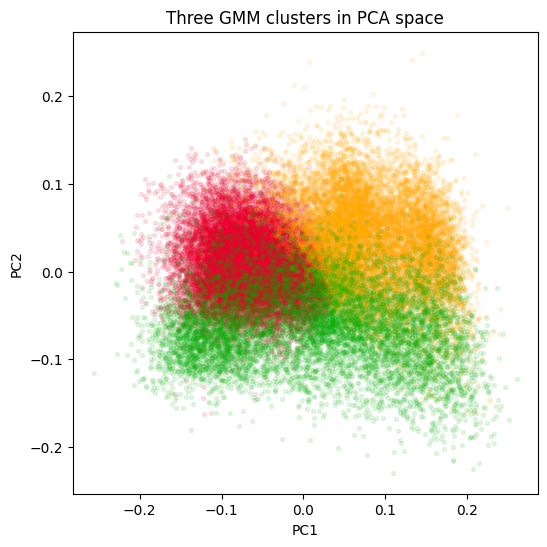

In [16]:
labels = gmm.fit_predict(latent_new)
probs = gmm.predict_proba(latent_new)

colors = {
    0: "#e9002d",
    1: "#ffaa00",
    2: "#00b000"
}

plt.figure(figsize=(6,6))

for k in range(3):

    mask = labels == k

    plt.scatter(
        pc_new[mask,0],
        pc_new[mask,1],
        color=colors[k],
        s=8,
        alpha=0.1,
        label=f"Cluster {k}"
    )


plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Three GMM clusters in PCA space")
plt.savefig("VAE_Clusters.png", dpi=600, bbox_inches="tight")
plt.show()

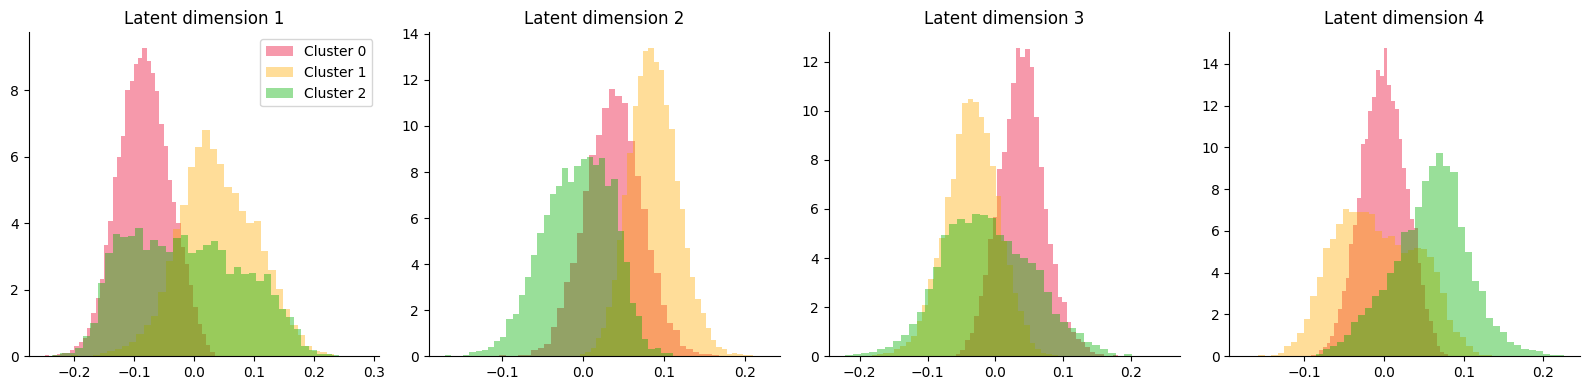

In [17]:
cluster_labels = gmm.fit_predict(latent_new)

cluster_colors = {
    0: "#e9002d",
    1: "#ffaa00",
    2: "#00b000"
}

fig, axes = plt.subplots(1, 4, figsize=(16,4))

for i, ax in enumerate(axes):

    ax.hist(
        latent_new[cluster_labels == 0, i],
        bins=40,
        alpha=0.4,
        density=True,
        color=cluster_colors[0],
        label='Cluster 0'
    )

    ax.hist(
        latent_new[cluster_labels == 1, i],
        bins=40,
        alpha=0.4,
        density=True,
        color=cluster_colors[1],
        label='Cluster 1'
    )

    ax.hist(
        latent_new[cluster_labels == 2, i],
        bins=40,
        alpha=0.4,
        density=True,
        color=cluster_colors[2],
        label='Cluster 2'
    )

    ax.set_title(f'Latent dimension {i+1}')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend()

plt.tight_layout()
plt.show()

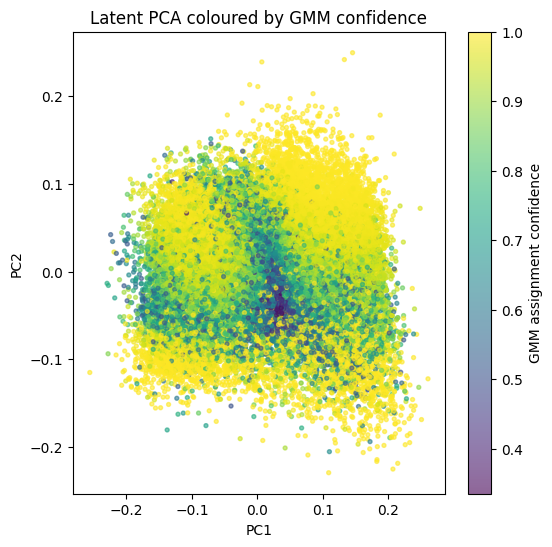

In [18]:
confidence = probs.max(axis=1)
plt.figure(figsize=(6,6))

plt.scatter(
    pc_new[:, 0],
    pc_new[:, 1],
    c=confidence,
    cmap="viridis",
    s=8,
    alpha=0.6
)

plt.colorbar(label="GMM assignment confidence")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Latent PCA coloured by GMM confidence")

plt.show()

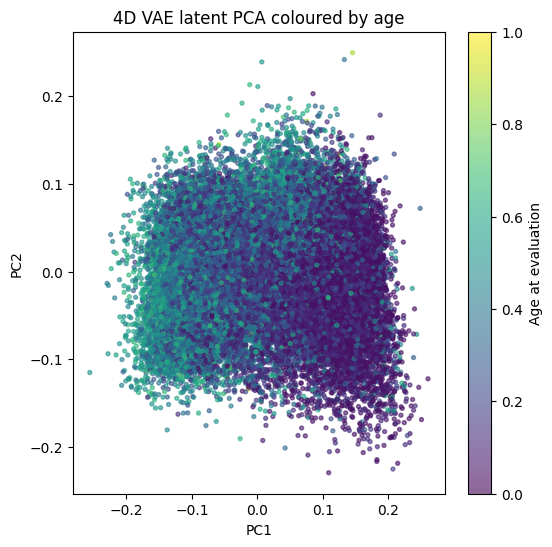

In [19]:
valid = ~df_full["age_at_eval_years"].isna()

plt.figure(figsize=(6,6))

plt.scatter(
    pc_new[valid, 0],
    pc_new[valid, 1],
    c=df_full.loc[valid, "age_at_eval_years"],
    cmap="viridis",
    s=8,
    alpha=0.6
)

plt.colorbar(label="Age at evaluation")

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("4D VAE latent PCA coloured by age")

plt.show()

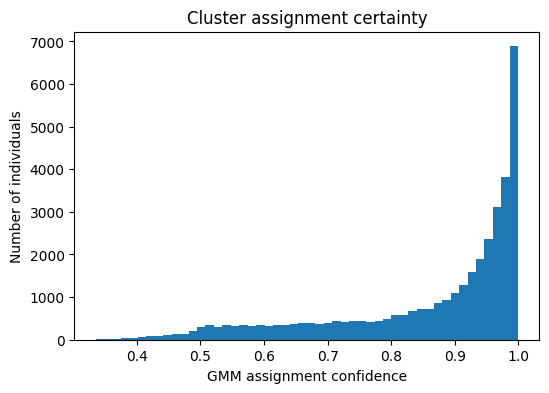

In [20]:
plt.figure(figsize=(6,4))

plt.hist(
    confidence,
    bins=50
)

plt.xlabel("GMM assignment confidence")
plt.ylabel("Number of individuals")

plt.title("Cluster assignment certainty")

plt.show()

In [21]:
strong = np.mean(confidence > 0.90)

moderate = np.mean(confidence > 0.75)

ambiguous = np.mean(confidence < 0.60)

print(f">90% confident: {strong:.3f}")
print(f">75% confident: {moderate:.3f}")
print(f"<60% confident: {ambiguous:.3f}")

>90% confident: 0.587
>75% confident: 0.785
<60% confident: 0.097


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline


X = original_df_new.drop(
    columns=["cluster", "confidence", "P_cluster0", "P_cluster1","P_cluster2"],
    errors="ignore"
)

y = original_df_new["cluster"]

X = X.select_dtypes(include=np.number)

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

model.fit(X, y)

coef = model.named_steps["logisticregression"].coef_[0]

importance_df_new = pd.DataFrame({
    "variable": X.columns,
    "coefficient": coef,
    "abs_coefficient": np.abs(coef)
})

importance_df_new = importance_df_new.sort_values(
    "abs_coefficient",
    ascending=False
)

In [23]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    model,
    X,
    y,
    cv=5
)

print("Mean CV accuracy:", scores.mean())

Mean CV accuracy: 0.8766757493188011


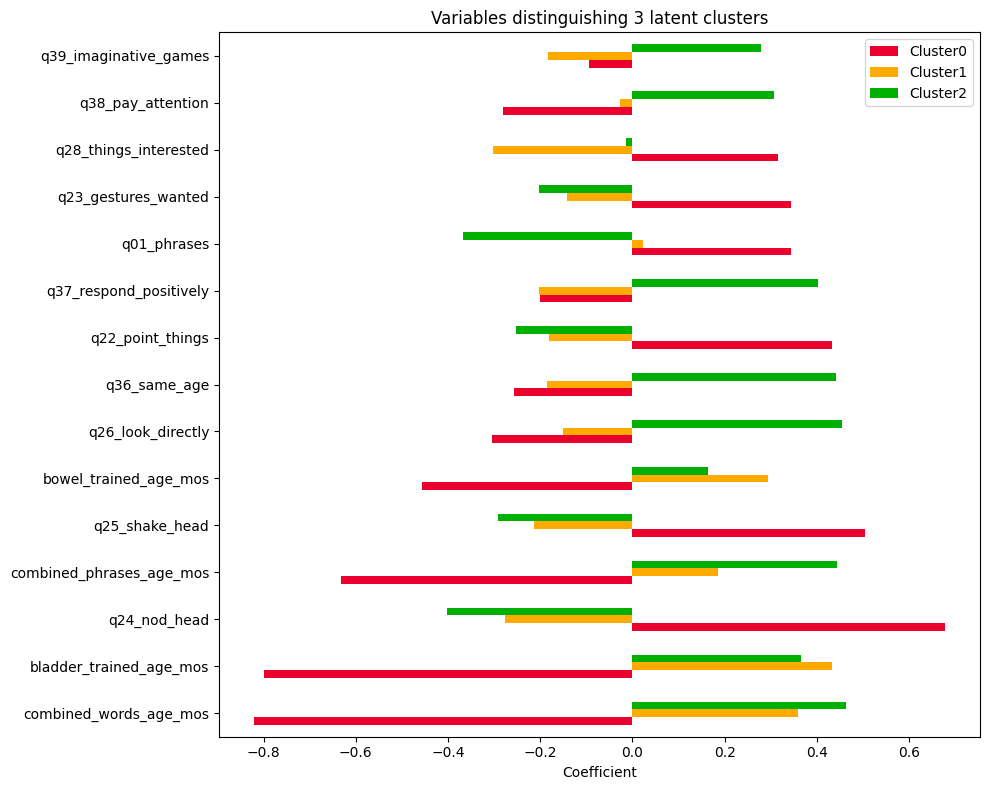

In [24]:
lr = model.named_steps["logisticregression"]

coef_df = pd.DataFrame(
    lr.coef_.T,
    index=X.columns,
    columns=[
        "Cluster0",
        "Cluster1",
        "Cluster2"
    ]
)

top_vars = (
    coef_df.abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(15)
    .index
)

cluster_colors = {
    "Cluster0": "#e9002d",
    "Cluster1": "#ffaa00",
    "Cluster2": "#00b000"
}

coef_df.loc[top_vars].plot(
    kind="barh",
    figsize=(10,8),
    color=[cluster_colors[c] for c in coef_df.columns]
)

plt.xlabel("Coefficient")
plt.title("Variables distinguishing 3 latent clusters")
plt.tight_layout()
plt.savefig("Latent_cluster_variables.png", dpi=600, bbox_inches="tight")
plt.show()

In [25]:
person_index = 2000

person_latent = latent_df_avg.iloc[
    person_index
].values.reshape(1,-1)

probs = gmm.predict_proba(person_latent)

print("Cluster 0:", probs[0,0])
print("Cluster 1:", probs[0,1])
print("Cluster 2:", probs[0,2])

print(
    "Assigned cluster:",
    np.argmax(probs)
)

print(
    "Confidence:",
    np.max(probs)
)

Cluster 0: 6.127208250139218e-09
Cluster 1: 0.00027997262557763084
Cluster 2: 0.9997200212472145
Assigned cluster: 2
Confidence: 0.9997200212472145


[[ 0.86616266  0.2607763  -0.41960868  0.07541087]
 [-0.23721214  0.59050024 -0.2536016  -0.72851   ]]
              PC1       PC2
Latent1  0.866163 -0.237212
Latent2  0.260776  0.590500
Latent3 -0.419609 -0.253602
Latent4  0.075411 -0.728510


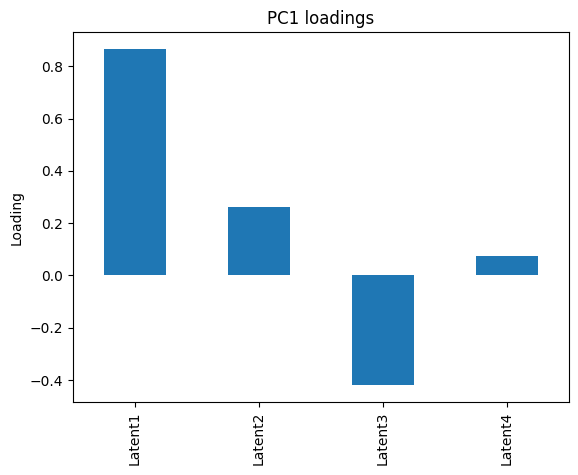

In [26]:
latent_2d = pca_new.fit_transform(latent_new)
print(pca_new.components_)


loading_df = pd.DataFrame(
    pca_new.components_.T,
    columns=["PC1", "PC2"],
    index=["Latent1", "Latent2", "Latent3", "Latent4"]
)

print(loading_df)

loading_df["PC1"].plot(kind="bar")
plt.ylabel("Loading")
plt.title("PC1 loadings")
plt.show()

              PC1       PC2
Latent1  0.866163 -0.237212
Latent2  0.260776  0.590500
Latent3 -0.419609 -0.253602
Latent4  0.075411 -0.728510


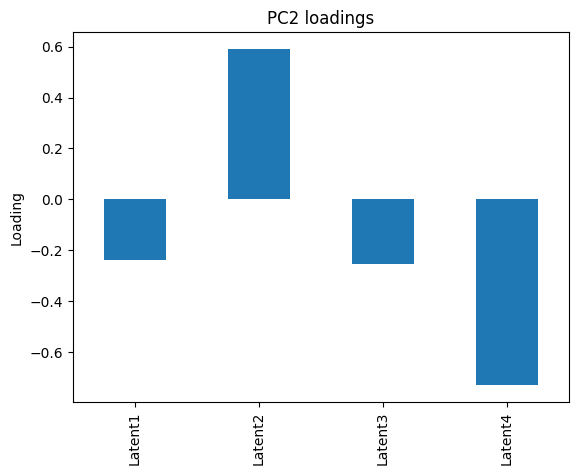

In [27]:
print(loading_df)

loading_df["PC2"].plot(kind="bar")
plt.ylabel("Loading")
plt.title("PC2 loadings")
plt.show()

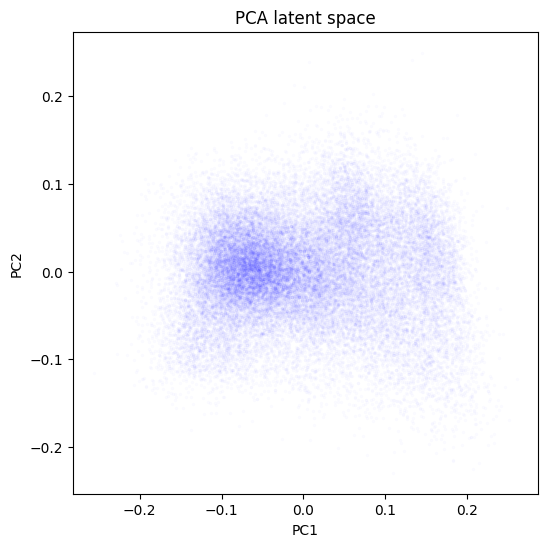

In [28]:
pca = PCA(n_components=2)

latent_pca = pca.fit_transform(latent_df_avg.values)

plt.figure(figsize=(6,6))

plt.scatter(
    latent_pca[:,0],
    latent_pca[:,1],
    color="blue",
    alpha=0.01,   # very important
    s=3
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA latent space")

plt.show()

In [29]:
pca = PCA(n_components=2)
latent_pca = pca.fit_transform(latent_df_avg.values)

# convert 4D dip-test direction into PCA coordinates
v_pca = pca.components_ @ v_best

# normalise
v_pca = v_pca / np.linalg.norm(v_pca)

print(v_pca)

[ 0.99182026 -0.12764233]


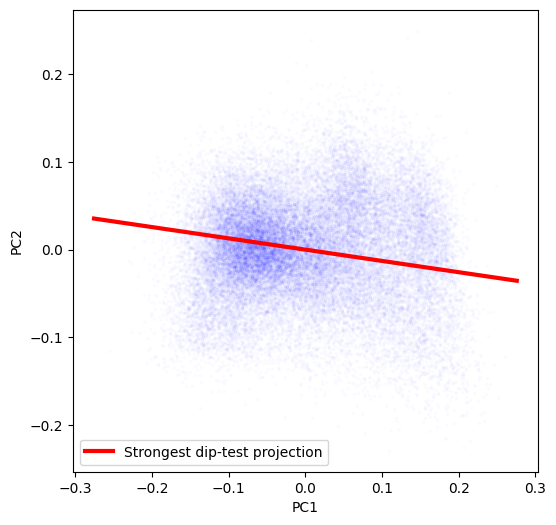

In [30]:
centre = latent_pca.mean(axis=0)

v_pca = pca.components_ @ v_best
v_pca = v_pca / np.linalg.norm(v_pca)

# scale based on actual PCA spread
scale = np.max(np.std(latent_pca, axis=0)) * 3

t = np.linspace(-scale, scale, 200)

x_line = centre[0] + t * v_pca[0]
y_line = centre[1] + t * v_pca[1]

plt.figure(figsize=(6,6))

plt.scatter(
    latent_pca[:,0],
    latent_pca[:,1],
    color="blue",
    alpha=0.01,
    s=3
)

plt.plot(
    x_line,
    y_line,
    color="red",
    linewidth=3,
    label="Strongest dip-test projection"
)

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [31]:
print(original_df_new["cluster"].value_counts())

cluster
0    16857
1    11678
2     8165
Name: count, dtype: int64


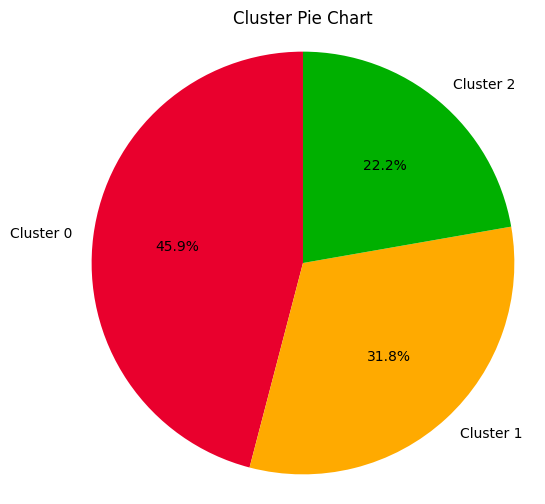

In [32]:
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']
sizes = [45.93188010899183, 31.82016348773842, 22.24795640326975]
colors = ["#e9002d","#ffaa00","#00b000"]

plt.figure(figsize=(6,6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Cluster Pie Chart")
plt.axis('equal')
plt.savefig("Cluster_pie.png", dpi=600, bbox_inches="tight")
plt.show()